# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
df = pd.read_csv('../../data/checker_submits.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df.drop('timestamp', axis=1)

In [3]:
cols = ["uid", "labname"]

ohe = OneHotEncoder()
transformed = ohe.fit_transform(df[cols])

encoded_cols = ohe.get_feature_names_out(cols)
encoded_df = pd.DataFrame(transformed.toarray(), columns=encoded_cols, index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [4]:
scaler = StandardScaler()
df[['numTrials', 'hour']] = scaler.fit_transform(df[['numTrials', 'hour']])
df.to_csv('../../data/dayofweek.csv', index=False)

In [5]:
feats = df.drop('dayofweek', axis=1)
labels = df['dayofweek']

baseline = [labels.mode()[0]] * len(labels)

accuracy_score(labels, baseline)


0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [6]:
lr = LogisticRegression(random_state=21, fit_intercept=False)
lr.fit(feats, labels)
lr_predict=lr.predict(feats)
accuracy_score(labels,lr_predict)

0.6405693950177936

In [7]:
def draw_barh(importances, feature_names, top_n=10):

    importances = np.asarray(importances)
    feature_names = np.asarray(feature_names)

    top_n = min(top_n, len(importances))

    index_top = np.argsort(importances)[-top_n:]
    top_feats = importances[index_top]
    top_names = feature_names[index_top]

    order = np.argsort(top_feats)
    top_feats = top_feats[order]
    top_names = top_names[order]

    plt.figure(figsize=(8, 5))
    plt.barh(range(top_n), top_feats, align="center")

    plt.yticks(range(top_n), top_names)

    plt.tight_layout()
    plt.show()


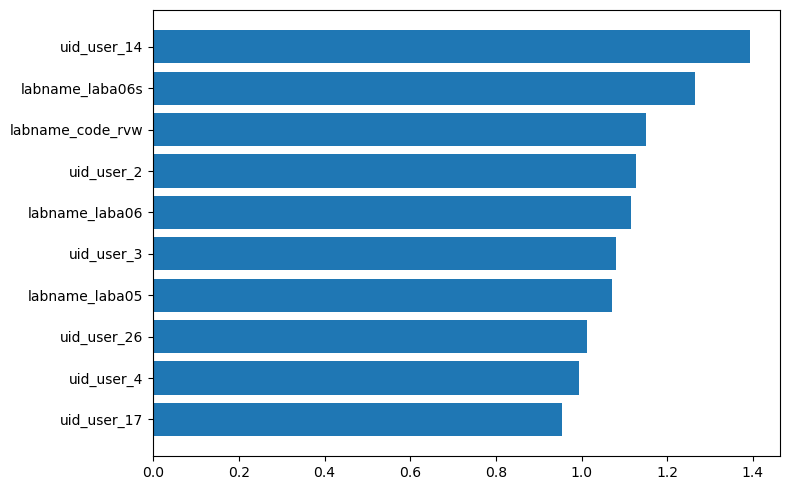

In [8]:
importances = np.mean(np.abs(lr.coef_), axis=0)

draw_barh(importances, feats.columns)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [9]:
svc_linear = SVC(kernel='linear', probability=True, random_state=21)
svc_linear.fit(feats, labels)
svc_linear_predict = svc_linear.predict(feats)
accuracy_score(svc_linear_predict, labels)

0.702846975088968

In [10]:
svc_ovr = SVC(kernel='linear', probability=True, random_state=21)
svc_ovr.fit(feats, labels)
svc_pred = svc_ovr.predict(feats)
  

In [11]:
svc = SVC(kernel='poly', probability=True, random_state=21)
svc.fit(feats, labels)
svc_predict = svc.predict(feats)
accuracy_score(svc_predict, labels)

0.8594306049822064

In [12]:
svc = SVC(kernel='sigmoid', probability=True, random_state=21)
svc.fit(feats, labels)
svc_predict = svc.predict(feats)
accuracy_score(svc_predict, labels)

0.3997627520759193

In [13]:
svc = SVC(kernel='rbf', probability=True, random_state=21)
svc.fit(feats, labels)
svc_predict = svc.predict(feats)
accuracy_score(svc_predict, labels)

0.8558718861209964

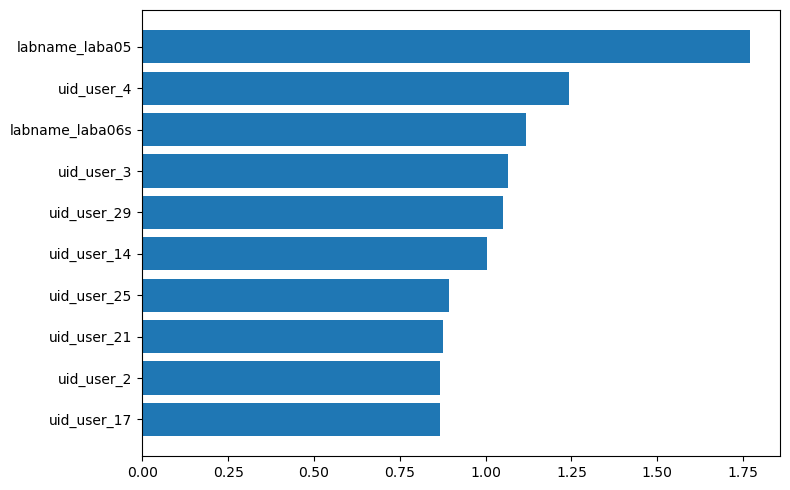

In [14]:
importances = np.mean(np.abs(svc_linear.coef_), axis=0)
draw_barh(importances, feats.columns)


### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [15]:
tree = DecisionTreeClassifier(max_depth=8, random_state=21)
tree.fit(feats, labels)
pred = tree.predict(feats)
accuracy_score(labels, pred)

0.7502965599051008

In [16]:
tree = DecisionTreeClassifier(max_depth=2, random_state=21)
tree.fit(feats, labels)
pred = tree.predict(feats)
accuracy_score(labels, pred)

0.4389086595492289

In [17]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(feats, labels)
pred = tree.predict(feats)
accuracy_score(labels, pred)

0.5516014234875445

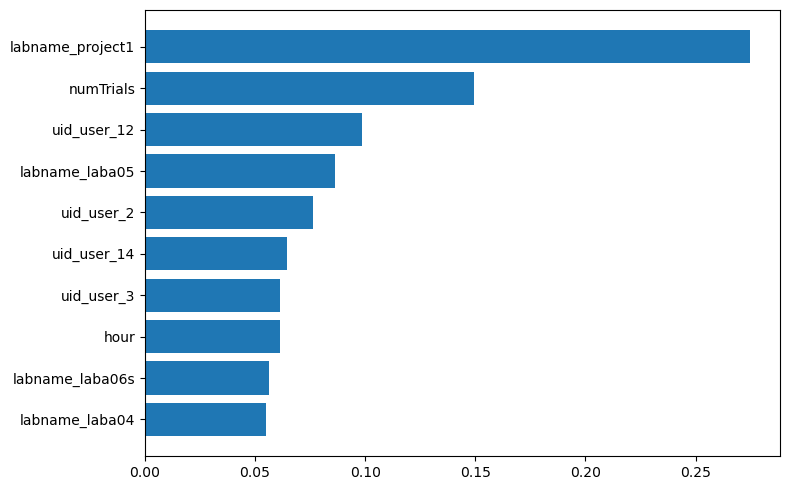

In [18]:
importances = np.array(tree.feature_importances_)
draw_barh(importances, feats.columns)


### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [19]:
forest = RandomForestClassifier(n_estimators=25, max_depth = 6, random_state=21)
forest.fit(feats, labels)
pred = forest.predict(feats)
accuracy_score(labels, pred)

0.6714116251482799

In [20]:
forest = RandomForestClassifier(n_estimators=50, max_depth = 12, random_state=21)
forest.fit(feats, labels)
pred = forest.predict(feats)
accuracy_score(labels, pred)

0.9264531435349941

In [21]:
forest = RandomForestClassifier(n_estimators=100, max_depth = 25, random_state=21)
forest.fit(feats, labels)
pred = forest.predict(feats)
accuracy_score(labels, pred)

1.0

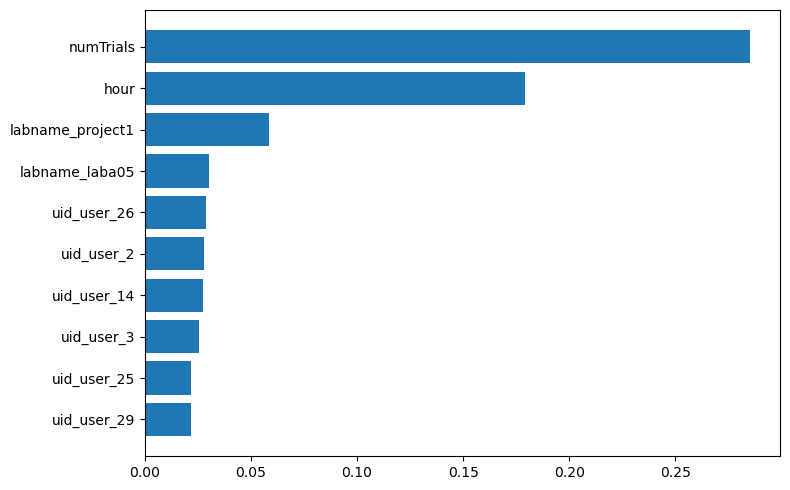

In [22]:
importances = np.array(forest.feature_importances_)
draw_barh(importances, feats.columns)